In [1]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
from scipy.stats import lognorm
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name in {"notebooks", "physics"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio\notebooks


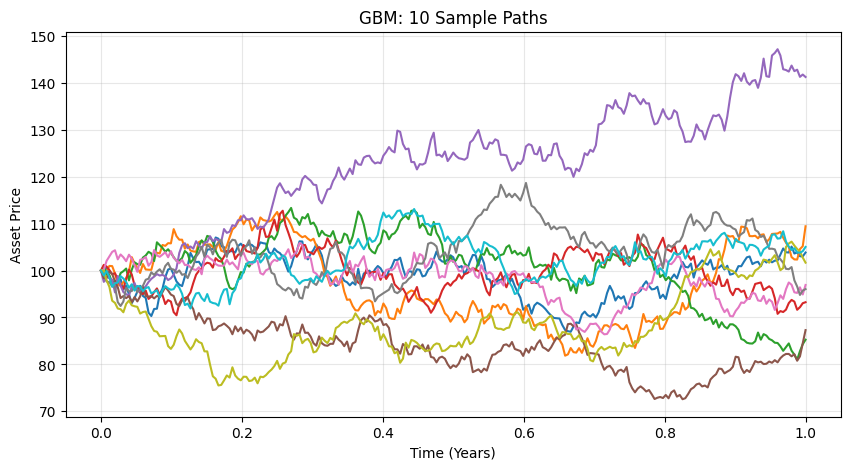

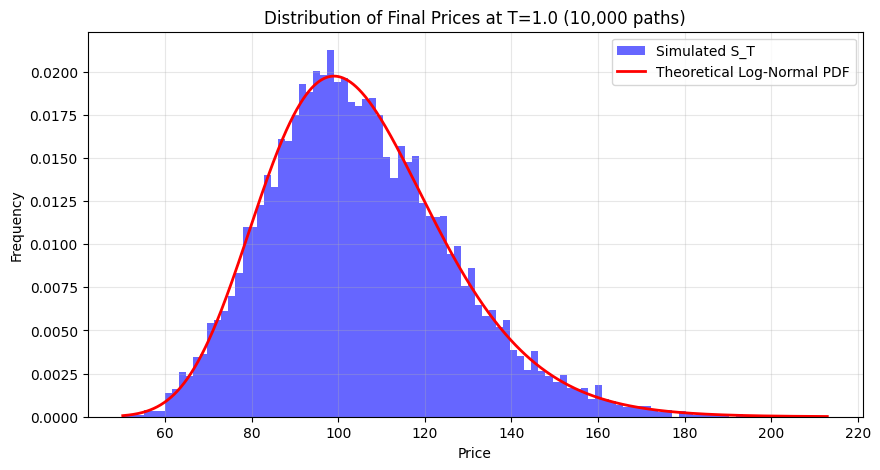

In [9]:
from src.physics.simulator import GBMSimulator

# 1. Define Parameters
s0 = 100.0
mu = 0.05
sigma = 0.20
T = 1.0
dt = 1 / 252  # Trading days
n_paths = 10000

# 2. Simulate
simulator = GBMSimulator(seed=42)
paths = simulator.simulate_paths(s0, mu, sigma, T, dt, n_paths)
time_grid = np.linspace(0, T, paths.shape[0])
final_prices = paths[-1, :]

# 3. Plot 10 Sample Paths
plt.figure(figsize=(10, 5))
plt.plot(time_grid, paths[:, :10], lw=1.5)
plt.title("GBM: 10 Sample Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Asset Price")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Plot Final Price Distribution vs Theoretical Log-Normal PDF
plt.figure(figsize=(10, 5))

# Empirical Histogram
plt.hist(final_prices, bins=100, density=True, alpha=0.6, color='b', label='Simulated S_T')

# Theoretical Log-Normal PDF
# For a log-normal distribution, shape = sigma*sqrt(T), scale = exp(mu_log)
# where mu_log is the mean of the underlying normal distribution.
mu_log = np.log(s0) + (mu - 0.5 * sigma**2) * T
shape = sigma * np.sqrt(T)
x_axis = np.linspace(final_prices.min(), final_prices.max(), 1000)
pdf_theoretical = lognorm.pdf(x_axis, s=shape, scale=np.exp(mu_log))

plt.plot(x_axis, pdf_theoretical, 'r-', lw=2, label='Theoretical Log-Normal PDF')
plt.title(f"Distribution of Final Prices at T={T} (10,000 paths)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

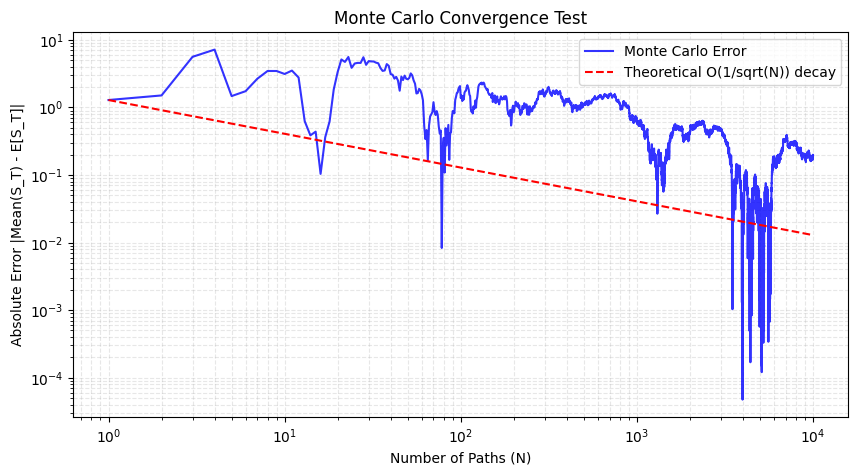

In [3]:
# 1. Theoretical Expected Value
expected_value_T = s0 * np.exp(mu * T)

# 2. Calculate the expanding sample mean across the 10,000 paths
# np.cumsum efficiently adds the prices, dividing by the index gives the running mean
N_array = np.arange(1, n_paths + 1)
running_mean = np.cumsum(final_prices) / N_array

# 3. Calculate absolute error
mc_error = np.abs(running_mean - expected_value_T)

# 4. Plot on Log-Log Scale
plt.figure(figsize=(10, 5))
plt.loglog(N_array, mc_error, label='Monte Carlo Error', color='b', alpha=0.8)

# 5. Add a reference line for 1/sqrt(N) decay
# We anchor it to the first error value for alignment
reference_line = mc_error[0] / np.sqrt(N_array)
plt.loglog(N_array, reference_line, 'r--', label='Theoretical O(1/sqrt(N)) decay')

plt.title("Monte Carlo Convergence Test")
plt.xlabel("Number of Paths (N)")
plt.ylabel("Absolute Error |Mean(S_T) - E[S_T]|")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

In [7]:
S_T = paths[-1, :]
r = 0.05
K = 100.0

# Calculate the payoff for every path simultaneously
payoffs = np.maximum(S_T - K, 0)

# Take the expected (mean) payoff and discount it to present value
C_0 = np.exp(-r * T) * np.mean(payoffs)
print(f"Monte Carlo Call Price: {C_0:.4f}")

Monte Carlo Call Price: 10.5948
